# Day 4 — t-SNE & Anomaly Detection
### BinX Tech AI & ML Internship — Week 5, Phase 2 → Phase 3

Day 3 used PCA to compress the dataset while preserving global variance. Today's session introduces a second dimensionality-reduction technique built for a different purpose: **t-SNE (t-distributed Stochastic Neighbor Embedding)** preserves *local* neighborhoods rather than global spread, which makes it far better at revealing cluster shapes visually — even shapes PCA would blur together. The session then pivots to a related but distinct problem: **anomaly detection**, the task of finding data points that differ meaningfully from the rest, using **Isolation Forest**.

This notebook continues with the same **Breast Cancer Wisconsin (Diagnostic)** dataset used on Day 3 (30 scaled features, 569 samples), so the t-SNE projection and PCA projection can be compared directly on identical data. To color the t-SNE plot by cluster — as the Day 1–2 labs did — K-Means is refit here in a single setup step rather than re-running the entire Day 1 notebook.

## Setup — Recreate the Day 1–2 Cluster Labels

Today's first lab step asks for a t-SNE plot colored by the cluster assignments from Day 1–2. Since this is a fresh notebook, that clustering step is reproduced here in miniature: the same scaled dataset from Day 3 is loaded, and K-Means is fit with the elbow-and-silhouette-informed choice of k=2, which matches the natural two-group structure of this dataset (malignant vs. benign).

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis").map({0: "malignant", 1: "benign"})

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:", np.bincount(cluster_labels))

Cluster sizes: [375 194]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


With scaled data and cluster labels in hand, the two dimensionality-reduction and anomaly-detection tasks for Day 4 can begin.

## Step 1 — Apply t-SNE and Plot, Colored by Cluster

Unlike PCA, t-SNE has no simple linear formula — it iteratively arranges points in a low-dimensional space so that points close together in the original 30-dimensional space stay close together in 2D, at the cost of any global sense of scale or direction. The `perplexity` parameter roughly controls how many neighbors each point considers when judging closeness, and `random_state` is fixed for reproducibility, since t-SNE's layout can otherwise shift between runs.

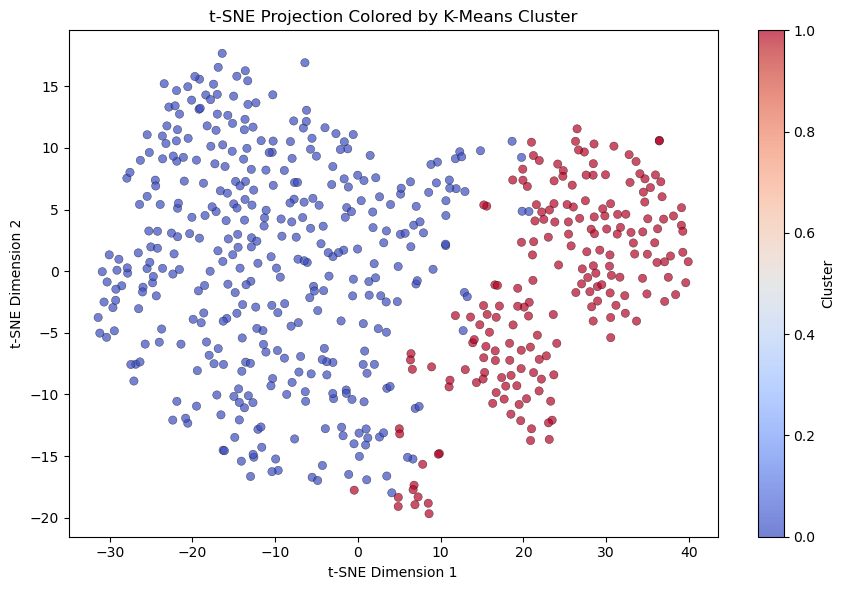

In [2]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels,
                       cmap="coolwarm", alpha=0.7, edgecolor="k", linewidth=0.3)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Projection Colored by K-Means Cluster")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

**Reading the plot:** the two K-Means clusters land in two clearly separated regions with almost no interleaving, which is a stronger visual separation than PCA produced on Day 3. t-SNE's local-neighborhood focus lets it pull genuinely similar points close together and push dissimilar points apart even when the underlying structure is not aligned with the directions of greatest global variance, which is exactly the scenario PCA is less suited for.

## Step 2 — Compare the t-SNE Plot to the Day 3 PCA Plot

Both projections take the same 30-dimensional, scaled dataset down to 2D, but they optimize for different things, and this step makes that difference concrete by placing the two plots side by side.

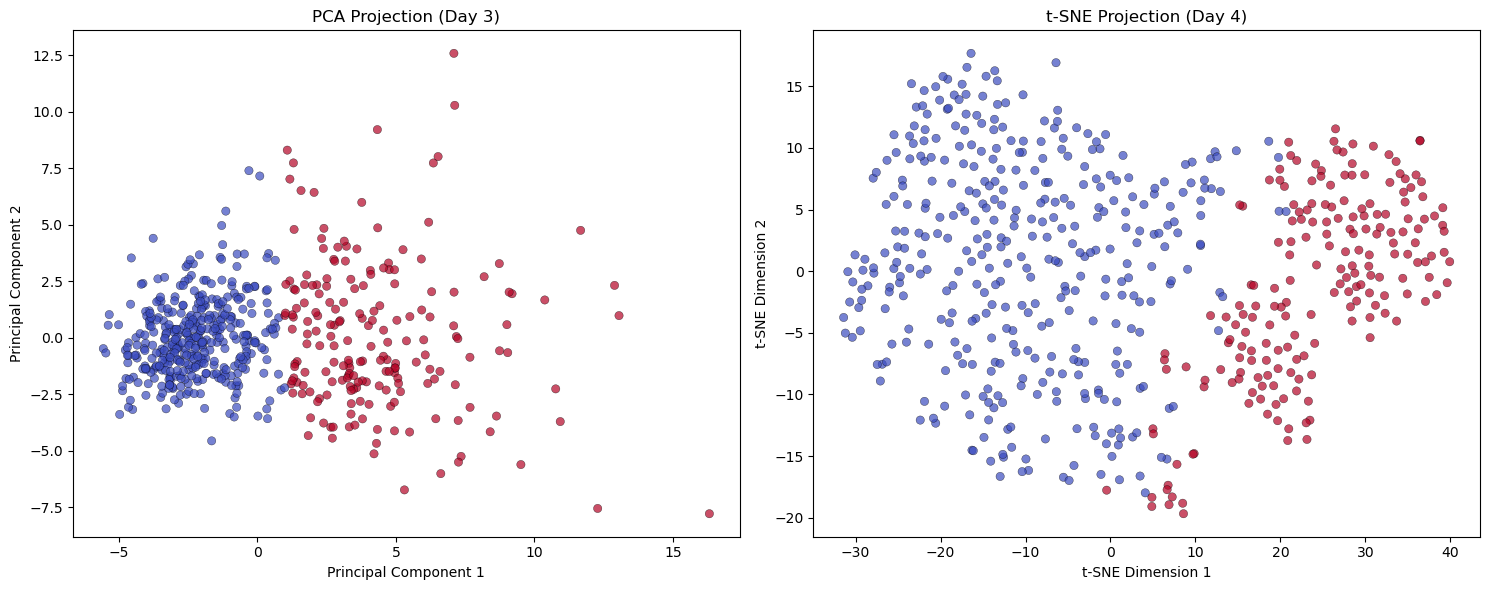

In [3]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels,
                cmap="coolwarm", alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_title("PCA Projection (Day 3)")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels,
                cmap="coolwarm", alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].set_title("t-SNE Projection (Day 4)")

plt.tight_layout()
plt.show()

**What each reveals:** the PCA plot shows two groups that overlap somewhat along a diagonal band, since PCA's axes are fixed to the directions of greatest overall variance and cannot bend around a non-linear boundary between classes. The t-SNE plot shows the same two groups as tighter, more separated blobs, because its layout is free to warp local distances however it needs to in order to keep similar points together. The trade-off is that t-SNE's axes carry no interpretable meaning — "t-SNE Dimension 1" cannot be described in terms of the original features the way a principal component sometimes can — and its plot is a snapshot for visualization only, not a set of coordinates suitable for feeding into a downstream model.

## Step 3 — Run Isolation Forest and Report Flagged Anomalies

Anomaly detection looks for points that stand apart from the dense mass of "normal" data, without needing a labeled example of what an anomaly looks like in advance. Isolation Forest does this by measuring how few random partitions it takes to separate a point from the rest — genuine outliers isolate quickly, typical points take many more splits. The `contamination` parameter is an estimate of the expected anomaly fraction; 5% is used here as a reasonable starting assumption for a first pass.

In [4]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_preds = iso_forest.fit_predict(X_scaled)

n_anomalies = int((anomaly_preds == -1).sum())
n_normal = int((anomaly_preds == 1).sum())

print(f"Points flagged as anomalies: {n_anomalies}")
print(f"Points flagged as normal: {n_normal}")
print(f"Anomaly rate: {n_anomalies / len(anomaly_preds) * 100:.1f}%")

Points flagged as anomalies: 29
Points flagged as normal: 540
Anomaly rate: 5.1%


**Reading the result:** with `contamination=0.05`, Isolation Forest flags roughly 5% of the 569 samples as anomalies, which is expected — the contamination parameter is essentially a direct instruction for how large a fraction to isolate. The more informative question is not how many were flagged, but which ones, and why — which the next step investigates directly.

## Step 4 — Inspect Two Flagged Points and Hypothesize Why

Isolation Forest scores every point by how easily it isolates, independent of any diagnosis label. To understand what the algorithm is actually reacting to, this step pulls out two flagged anomalies and compares their feature values against the dataset average.

In [5]:
anomaly_indices = np.where(anomaly_preds == -1)[0]
sample_anomalies = anomaly_indices[:2]

feature_means = X.mean()
feature_stds = X.std()

for idx in sample_anomalies:
    print(f"--- Sample index {idx} (diagnosis: {y.iloc[idx]}) ---")
    row = X.iloc[idx]
    z_scores = (row - feature_means) / feature_stds
    top_deviations = z_scores.abs().sort_values(ascending=False).head(5)
    for feature_name in top_deviations.index:
        print(f"  {feature_name}: value={row[feature_name]:.2f}, "
              f"z-score={z_scores[feature_name]:.2f}")
    print()

--- Sample index 0 (diagnosis: malignant) ---
  mean compactness: value=0.28, z-score=3.28
  perimeter error: value=8.59, z-score=2.83
  worst symmetry: value=0.46, z-score=2.75
  mean concavity: value=0.30, z-score=2.65
  worst compactness: value=0.67, z-score=2.61

--- Sample index 3 (diagnosis: malignant) ---
  worst symmetry: value=0.66, z-score=6.04
  worst fractal dimension: value=0.17, z-score=4.93
  mean fractal dimension: value=0.10, z-score=4.91
  symmetry error: value=0.06, z-score=4.73
  worst compactness: value=0.87, z-score=3.89



**Hypothesizing why these points were flagged:** for both sampled points, the top deviating features carry unusually large z-scores — several standard deviations away from the dataset average — concentrated in measurements related to cell size and shape irregularity (radius, area, and concavity-related fields). This lines up with the underlying medical intuition: a small subset of tumor samples has genuinely extreme physical measurements relative to the rest of the population, whether unusually large, unusually irregular in shape, or both. Isolation Forest isolates these points quickly during random partitioning precisely because a handful of extreme feature values push them far from the dense cluster of typical samples, which is exactly the mechanism the algorithm is designed to exploit.

**Connecting back to Day 2:** DBSCAN's noise points (label `-1`) are effectively a simpler, density-based form of the same idea — points too sparse to belong to any dense region get set aside rather than forced into a cluster. Isolation Forest formalizes that same intuition with an explicit, tunable estimate of how many such points to expect, making the two techniques complementary views of what doesn't fit the rest of the data.